## 2장 1강: 선형 회귀 모델과 오차 평가지표
### 3. 주택 가격 예측 선형 회귀 구현
#### 3.1 데이터 불러오기 및 확인

USA 주택 데이터(CSV) 불러오기

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('usa_housing.csv')
df.head()

,Price,Bedrooms,Bathrooms,SquareFeet,YearBuilt,GarageSpaces,LotSize,ZipCode,CrimeRate,SchoolRating
0,221958,1,1.9,4827,1979,2,1.45,82240,48.60,5
1,771155,2,2.0,1035,1987,2,1.75,74315,92.03,9
2,231932,1,3.0,2769,1982,1,1.46,79249,52.08,3
3,465838,3,3.3,2708,1907,3,1.62,80587,61.65,1
4,359178,4,3.4,1175,1994,2,0.74,20756,15.66,4


데이터 전처리: 최근 데이터 + 범죄율이 낮은 데이터로 필터링

In [9]:
latest_year = df['YearBuilt'].max()

df = df[(df['YearBuilt']>2015)&(df['CrimeRate']<40)]
df.head()

,Price,Bedrooms,Bathrooms,SquareFeet,YearBuilt,GarageSpaces,LotSize,ZipCode,CrimeRate,SchoolRating
9,737147,3,2.6,4191,2017,0,1.65,66549,37.60,3
33,586232,4,1.3,3854,2021,2,1.39,30103,26.93,2
112,616588,2,1.2,3872,2016,0,0.17,61112,20.98,8
119,979858,5,3.8,4307,2020,0,0.38,41822,37.14,4
189,161087,5,2.4,964,2021,1,0.24,34022,12.80,3


그래프로 데이터 분포 확인하기

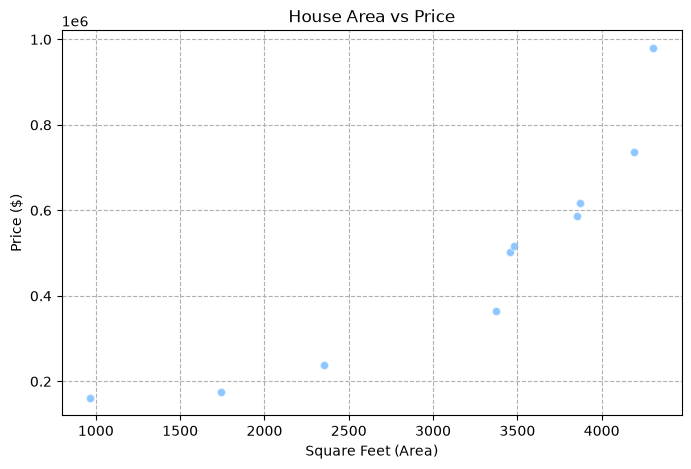

In [10]:
plt.figure(figsize=(8, 5))
plt.scatter(df['SquareFeet'], df['Price'], color='dodgerblue', alpha=0.5, edgecolor='w')
plt.title('House Area vs Price')
plt.xlabel('Square Feet (Area)')
plt.ylabel('Price ($)')
plt.grid(True, linestyle='--')
plt.show()

#### 3.2 모델 학습 및 결과 시각화

특성(Feature, 방 면적)과 정답(Label, 집값) 나누기

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Scikit-learn은 입력 데이터를 2차원 표 형태로 기대하므로 대괄호를 2개 씁니다.
X = df[['SquareFeet']]
y = df['Price']

X.shape, y.shape

((10, 1), (10,))

선형 회귀 모델 준비 및 학습(fit)

In [26]:
from sklearn import set_config
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

model = LinearRegression()
model.fit(X, y);

print(model.coef_, model.intercept_)

[210.23217333] -176577.39806530828


In [41]:
from sklearn import set_config
set_config(display="diagram")

model;

In [34]:
import sys
import locale

print("UTF8 mode:", sys.flags.utf8_mode)
print("Encoding:", locale.getpreferredencoding(False))

UTF8 mode: 0
Encoding: cp949


학습된 모델로 집값 예측해보기

In [27]:
y_pred = model.predict(X)
y_pred

array([704505.64035344, 633657.39794181, 637441.57706172, 728892.57245951,
        26086.41702314, 189857.28004585, 318519.37012275, 532535.72257092,
       550195.22513049, 555240.79729037])

오차 점수 확인하기

In [28]:
mse = mean_squared_error(y, y_pred)
mae = mean_absolute_error(y, y_pred)

print(f"컴퓨터가 찾은 기울기(w): {model.coef_}")
print(f"컴퓨터가 찾은 기본값(b): {model.intercept_:.2f}")
print(f"오차 제곱 평균(MSE): {mse:.2f}")
print(f"오차 절대값 평균(MAE): {mae:.2f}")

컴퓨터가 찾은 기울기(w): [210.23217333]
컴퓨터가 찾은 기본값(b): -176577.40
오차 제곱 평균(MSE): 12374713026.51
오차 절대값 평균(MAE): 83721.47


모델이 찾은 직선 그래프로 그려보기

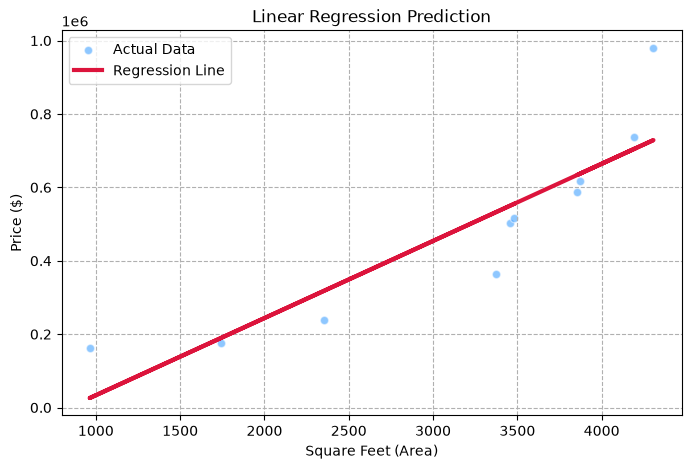

In [29]:
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='dodgerblue', alpha=0.5, edgecolor='w', label='Actual Data')
plt.plot(X, y_pred, color='crimson', linewidth=3, label='Regression Line')
plt.title('Linear Regression Prediction')
plt.xlabel('Square Feet (Area)')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('usa_housing.csv')
df.head()


,Price,Bedrooms,Bathrooms,SquareFeet,YearBuilt,GarageSpaces,LotSize,ZipCode,CrimeRate,SchoolRating
0,221958,1,1.9,4827,1979,2,1.45,82240,48.60,5
1,771155,2,2.0,1035,1987,2,1.75,74315,92.03,9
2,231932,1,3.0,2769,1982,1,1.46,79249,52.08,3
3,465838,3,3.3,2708,1907,3,1.62,80587,61.65,1
4,359178,4,3.4,1175,1994,2,0.74,20756,15.66,4


In [51]:
filtered_df=df[df['YearBuilt']>2000].reset_index(drop=True)
filtered_df

,Price,Bedrooms,Bathrooms,SquareFeet,YearBuilt,GarageSpaces,LotSize,ZipCode,CrimeRate,SchoolRating
0,737147,3,2.6,4191,2017,0,1.65,66549,37.60,3
1,421879,5,1.2,1865,2004,2,1.95,54843,31.69,8
2,818315,3,3.5,2936,2008,1,0.74,70963,87.93,2
3,586232,4,1.3,3854,2021,2,1.39,30103,26.93,2
4,484681,1,3.7,2951,2016,3,0.98,82982,68.53,1
5,627035,2,1.0,2770,2014,3,1.51,39301,48.84,1
6,165725,5,1.4,2002,2013,0,0.80,28752,41.34,2
7,373538,4,1.9,3397,2015,1,1.02,20699,57.72,4
8,356840,3,3.9,3043,2005,3,1.23,15782,81.18,3
9,573254,3,1.1,3445,2002,3,1.83,98177,74.17,4


In [52]:
print('2000년 이후 데이터 갯수', len(filtered_df))

2000년 이후 데이터 갯수 54


In [54]:
plt.figure(figsize=(10,6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

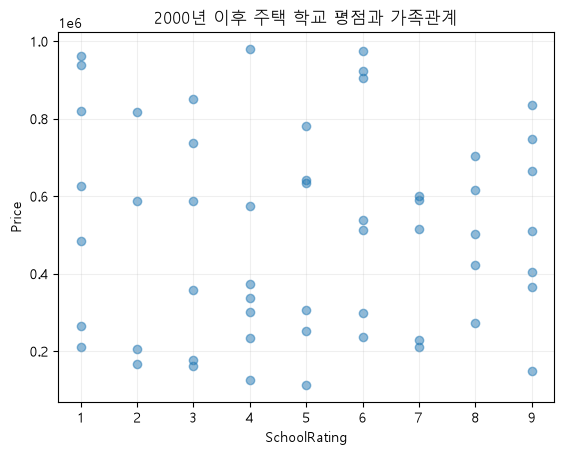

In [62]:
plt.scatter(
    filtered_df['SchoolRating'],
    filtered_df['Price'],
    alpha=0.5
)

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

plt.title('2000년 이후 주택 학교 평점과 가족관계')
plt.xlabel("SchoolRating")
plt.ylabel("Price")

plt.grid(alpha=0.2)
plt.show()


In [63]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Scikit-learn은 입력 데이터를 2차원 표 형태로 기대하므로 대괄호를 2개 씁니다.
X = filtered_df[['SchoolRating']]
y = filtered_df['Price']

X.shape, y.shape

((54, 1), (54,))

In [64]:
from sklearn import set_config
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

model = LinearRegression()
model.fit(X, y);

print(model.coef_, model.intercept_)

[-2216.81807051] 517149.0499464313


In [65]:
y_pred = model.predict(X)
y_pred

array([510498.59573491, 499414.50538238, 512715.41380542, 512715.41380542,
       514932.23187592, 514932.23187592, 512715.41380542, 508281.7776644 ,
       510498.59573491, 508281.7776644 , 506064.9595939 , 503848.14152339,
       499414.50538238, 503848.14152339, 499414.50538238, 503848.14152339,
       510498.59573491, 497197.68731187, 508281.7776644 , 506064.9595939 ,
       514932.23187592, 499414.50538238, 508281.7776644 , 497197.68731187,
       497197.68731187, 508281.7776644 , 497197.68731187, 506064.9595939 ,
       508281.7776644 , 514932.23187592, 501631.32345289, 508281.7776644 ,
       503848.14152339, 503848.14152339, 497197.68731187, 512715.41380542,
       503848.14152339, 514932.23187592, 510498.59573491, 510498.59573491,
       506064.9595939 , 506064.9595939 , 503848.14152339, 497197.68731187,
       501631.32345289, 497197.68731187, 501631.32345289, 514932.23187592,
       499414.50538238, 501631.32345289, 506064.9595939 , 514932.23187592,
       501631.32345289, 5

In [66]:
mse = mean_squared_error(y, y_pred)
mae = mean_absolute_error(y, y_pred)

print(f"컴퓨터가 찾은 기울기(w): {model.coef_}")
print(f"컴퓨터가 찾은 기본값(b): {model.intercept_:.2f}")
print(f"오차 제곱 평균(MSE): {mse:.2f}")
print(f"오차 절대값 평균(MAE): {mae:.2f}")

컴퓨터가 찾은 기울기(w): [-2216.81807051]
컴퓨터가 찾은 기본값(b): 517149.05
오차 제곱 평균(MSE): 66847213624.74
오차 절대값 평균(MAE): 222660.71


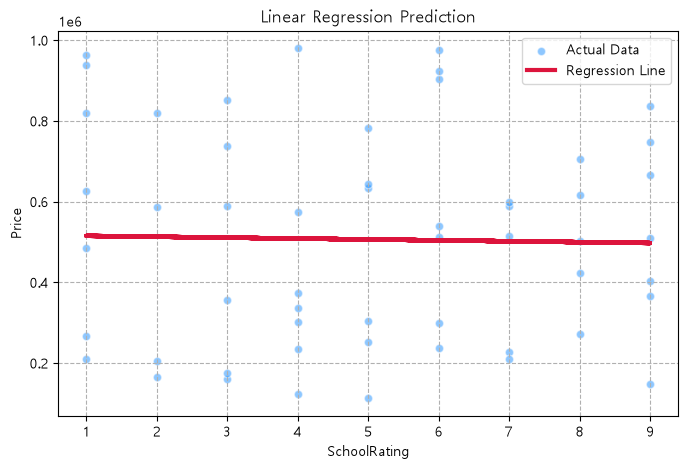

In [68]:
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='dodgerblue', alpha=0.5, edgecolor='w', label='Actual Data')
plt.plot(X, y_pred, color='crimson', linewidth=3, label='Regression Line')
plt.title('Linear Regression Prediction')
plt.xlabel('SchoolRating')
plt.ylabel('Price')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()